# Team 01 — Polynomial Model Complexity and Generalization

**Research question:** When does increasing model complexity stop improving generalization?

This notebook investigates how polynomial degree affects training and validation/test performance on the UCI Wine Quality dataset.

## 1. Investigation Plan

We will compare Polynomial Regression models with degrees **1, 2, 3, 4, and 5** while keeping the dataset, split, preprocessing strategy, and learning algorithm controlled.

Primary metric: **RMSE**

Supporting metrics: **MAE** and **R²**

The test set will be kept separate and used only for the final evaluation after model complexity is selected using validation performance.

In [ ]:
# Cell 1 — Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
print('Libraries imported successfully.')

Libraries imported successfully.


In [ ]:
# Cell 2 — Load the UCI Wine Quality (red wine) dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
# Cell 3 — Inspect the dataset
print('Columns:')
print(df.columns.tolist())

print('\nMissing values:')
print(df.isna().sum())

print('\nTarget distribution:')
print(df['quality'].value_counts().sort_index())

print('\nSummary statistics:')
display(df.describe().T)

Columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Target distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


### Why we inspect the data first

Before training anything, we need to understand the number of observations, available features, missing values, feature scales, and the target variable. This supports the dataset justification required in the course project.

In [ ]:
# Cell 4 — Separate features and target
X = df.drop(columns='quality')
y = df['quality']

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)
print('Number of input features:', X.shape[1])

Feature matrix shape: (1599, 11)
Target shape: (1599,)
Number of input features: 11


In [ ]:
# Cell 5 — Create train / validation / test splits
# 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

print('Train:', X_train.shape, y_train.shape)
print('Validation:', X_val.shape, y_val.shape)
print('Test:', X_test.shape, y_test.shape)

Train: (1119, 11) (1119,)
Validation: (240, 11) (240,)
Test: (240, 11) (240,)


## 2. Build the polynomial regression experiment

The only experimental variable we change is **polynomial degree**. Everything else remains controlled.

The pipeline standardizes the original features, creates polynomial terms, standardizes the expanded feature matrix, and fits Linear Regression. Keeping preprocessing inside the pipeline prevents validation/test information from leaking into training.

In [ ]:
# Cell 6 — Train and evaluate polynomial models for degrees 1 to 5
degrees = [1, 2, 3, 4, 5]
results = []

for degree in degrees:
    model = Pipeline([
        ('input_scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('poly_scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

    train_mae = mean_absolute_error(y_train, train_pred)
    val_mae = mean_absolute_error(y_val, val_pred)

    train_r2 = r2_score(y_train, train_pred)
    val_r2 = r2_score(y_val, val_pred)

    n_poly_features = model.named_steps['poly'].n_output_features_

    results.append({
        'degree': degree,
        'poly_features': n_poly_features,
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'train_mae': train_mae,
        'val_mae': val_mae,
        'train_r2': train_r2,
        'val_r2': val_r2,
        'generalization_gap_rmse': val_rmse - train_rmse,
        'generalization_gap_r2': train_r2 - val_r2,
    })

results_df = pd.DataFrame(results)
results_df

,degree,poly_features,train_rmse,val_rmse,train_mae,val_mae,train_r2,val_r2,generalization_gap_rmse,generalization_gap_r2
0,1,11,6.486807e-01,0.637445,4.951875e-01,0.518364,0.361198,0.318017,-0.011236,0.043181
1,2,77,6.014819e-01,0.627450,4.642753e-01,0.515270,0.450776,0.339237,0.025968,0.111540
2,3,363,4.544370e-01,0.856336,3.403117e-01,0.617836,0.686490,-0.230769,0.401899,0.917259
3,4,1364,1.343687e-13,18.789732,7.132692e-14,6.549741,1.000000,-591.555518,18.789732,592.555518
4,5,4367,3.501685e-14,9.393747,1.878985e-14,3.622357,1.000000,-147.103588,9.393747,148.103588


In [ ]:
# Cell 7 — Identify the best degree using validation RMSE
best_row = results_df.loc[results_df['val_rmse'].idxmin()]

print(f"Best degree according to validation RMSE: {int(best_row['degree'])}")
print(f"Validation RMSE: {best_row['val_rmse']:.4f}")
print(f"Validation R²: {best_row['val_r2']:.4f}")

Best degree according to validation RMSE: 2
Validation RMSE: 0.6274
Validation R²: 0.3392


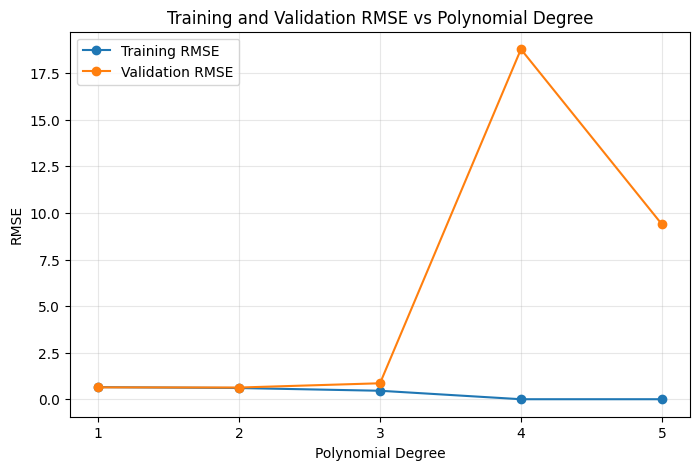

In [ ]:
# Cell 8 — Plot training and validation RMSE
plt.figure(figsize=(8, 5))
plt.plot(results_df['degree'], results_df['train_rmse'], marker='o', label='Training RMSE')
plt.plot(results_df['degree'], results_df['val_rmse'], marker='o', label='Validation RMSE')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('Training and Validation RMSE vs Polynomial Degree')
plt.xticks(degrees)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

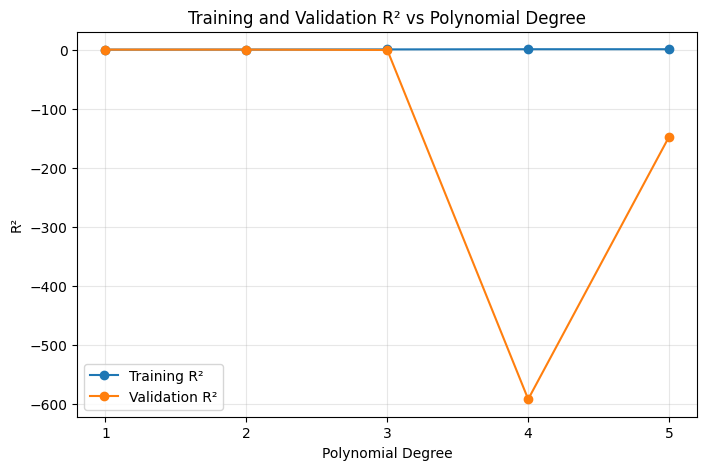

In [ ]:
# Cell 9 — Plot training and validation R²
plt.figure(figsize=(8, 5))
plt.plot(results_df['degree'], results_df['train_r2'], marker='o', label='Training R²')
plt.plot(results_df['degree'], results_df['val_r2'], marker='o', label='Validation R²')
plt.xlabel('Polynomial Degree')
plt.ylabel('R²')
plt.title('Training and Validation R² vs Polynomial Degree')
plt.xticks(degrees)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

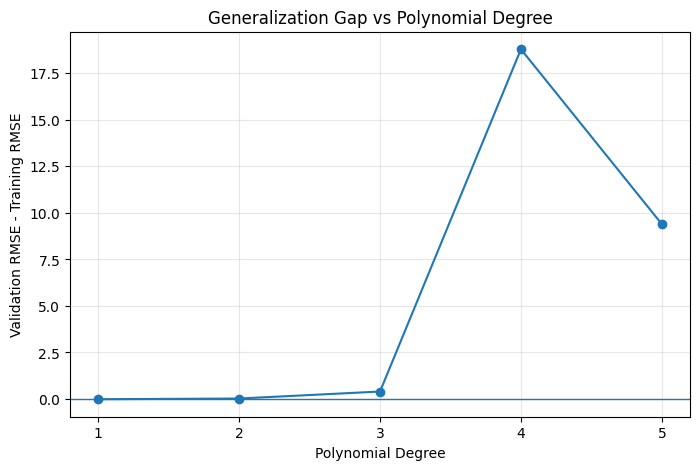

In [ ]:
# Cell 10 — Plot the generalization gap
plt.figure(figsize=(8, 5))
plt.plot(
    results_df['degree'],
    results_df['generalization_gap_rmse'],
    marker='o'
)
plt.axhline(0, linewidth=1)
plt.xlabel('Polynomial Degree')
plt.ylabel('Validation RMSE - Training RMSE')
plt.title('Generalization Gap vs Polynomial Degree')
plt.xticks(degrees)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Cell 11 — Final test evaluation of the degree selected by validation performance
best_degree = int(best_row['degree'])

final_model = Pipeline([
    ('input_scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('poly_scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

final_model.fit(X_train, y_train)
test_pred = final_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
test_mae = mean_absolute_error(y_test, test_pred)
test_r2 = r2_score(y_test, test_pred)

print(f'Chosen degree: {best_degree}')
print(f'Test RMSE: {test_rmse:.4f}')
print(f'Test MAE: {test_mae:.4f}')
print(f'Test R²: {test_r2:.4f}')

Chosen degree: 2
Test RMSE: 0.6548
Test MAE: 0.5078
Test R²: 0.3621


## 3. Interpretation checklist

Do not write conclusions before looking at the results. After running the experiment, answer:

1. Does training RMSE generally decrease as degree increases?
2. Does validation RMSE initially improve, then level off or worsen?
3. At what degree is validation performance best?
4. At what degree does the training/validation gap become noticeably larger?
5. Does the evidence support underfitting at low degrees?
6. Does the evidence support overfitting at higher degrees?
7. How many polynomial features are generated at each degree?
8. Does the final test result support the validation-based choice?

## 4. Important methodological note

The values produced by this notebook are experimental evidence. They should be reported exactly as obtained. If the observed pattern differs from the hypothesis, that is a valid result and should be analysed rather than changed.